In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [2]:
def make_cos_phi_operator(N):
    """
    Constructs the cos(φ) operator in the charge basis for a given cutoff N.
    
    Parameters:
    N (int): The cutoff for the charge basis, resulting in a (2N+1)x(2N+1) matrix.
    
    Returns:
    Qobj: The cos(φ) operator as a QuTiP quantum object.
    """
    dim = 2 * N + 1
    cos_phi_np = np.zeros((dim, dim), dtype=complex)

    for n in range(-N, N + 1): # loops from -N to N inclusive
        if n + 1 <= N:
            cos_phi_np[n + N, n + 1 + N] = 0.5
        if n - 1 >= -N:
            cos_phi_np[n + N, n - 1 + N] = 0.5
    
    return qt.Qobj(cos_phi_np, dims=[[dim], [dim]])

def make_Hamiltonian(eta, ng, N):
    """
    Constructs the Hamiltonian for a Cooper pair box in the charge basis.
    
    Parameters:
    eta (float): sqrt(8 * Ej / Ec)
    ng (float): Offset charge.
    N (int): Cutoff for the charge basis.
    
    Returns:
    Qobj: The Hamiltonian as a QuTiP quantum object.
    """
    dim = 2 * N + 1
    charge_op = qt.Qobj(np.diag(np.arange(-N, N + 1)), dims=[[dim], [dim]])
    I = qt.qeye(dim)
    cos_phi_op = make_cos_phi_operator(N)
    
    H = (eta / 2) * (charge_op - ng * I)**2 - (1 / eta) * cos_phi_op
    return H

# a

In [3]:
N = 100
f_p = np.sqrt(8) # EJ, EC are in GHz and product set to 1. f_p is the plasma frequency in GHz.
EJ_over_EC = 16

N_random = 100
times = np.linspace(0, 50, 10000) # Time points for the simulation, in ns

ng_values = np.random.uniform(0, 1, N_random) # Random ng values
average_X = np.zeros(len(times), dtype = float)
for ng in ng_values:
    eta = np.sqrt(8 / EJ_over_EC)  # Calculate eta from the given ratio of Ej/Ec
    H = f_p * make_Hamiltonian(eta, ng, N) # Construct the Hamiltonian for the current ng. Hamiltonian is in GHz.
    evals = H.eigenenergies() # Get eigenvalues of the Hamiltonian  

    H_for_sesolve = 2* np.pi * qt.Qobj(np.diag(evals[:2] - evals[0]), dims=[[2], [2]]) # Hamiltonian for the two-level system
    psi_0 = (qt.fock(2,0) + qt.fock(2,1)).unit() # Initial state as a superposition of ground and excited states
    result = qt.sesolve(H_for_sesolve, psi_0, times, e_ops = [qt.sigmax()]) # Time evolution of the state, get expectation value of sigma_x
    average_X += np.real(result.expect[0])/ N_random # Accumulate the expectation values for averaging

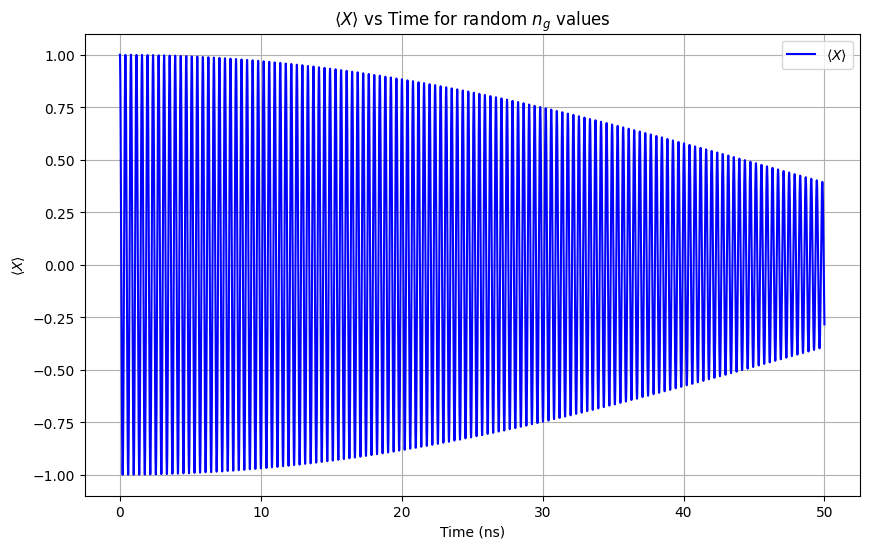

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(times, average_X, label=r'$\langle X \rangle$', color='blue')
plt.title(r'$\langle X \rangle$ vs Time for random $n_g$ values')
plt.xlabel('Time (ns)')
plt.ylabel(r'$\langle X \rangle$')
plt.grid()
plt.legend()
plt.show()

# b

In [ ]:
N = 100
f_p = np.sqrt(8) # EJ, EC are in GHz and product set to 1. f_p is the plasma frequency in GHz.
EJ_over_EC = 14

N_random = 100
times = np.linspace(0, 100, 10000) # Time points for the simulation, in ns

ng_values = np.random.uniform(0, 1, N_random) # Random ng values
average_X = np.zeros(len(times), dtype = float)
for ng in ng_values:
    eta = np.sqrt(8 / EJ_over_EC)  # Calculate eta from the given ratio of Ej/Ec
    H = f_p * make_Hamiltonian(eta, ng, N) # Construct the Hamiltonian for the current ng. Hamiltonian is in GHz.
    evals = H.eigenenergies() # Get eigenvalues of the Hamiltonian  

    H_for_sesolve = 2* np.pi * qt.Qobj(np.diag(evals[:2] - evals[0]), dims=[[2], [2]]) # Hamiltonian for the two-level system
    psi_0 = (qt.fock(2,0) + qt.fock(2,1)).unit() # Initial state as a superposition of ground and excited states
    result = qt.sesolve(H_for_sesolve, psi_0, times, e_ops = [qt.sigmax()]) # Time evolution of the state, get expectation value of sigma_x
    average_X += np.real(result.expect[0])/ N_random # Accumulate the expectation values for averaging

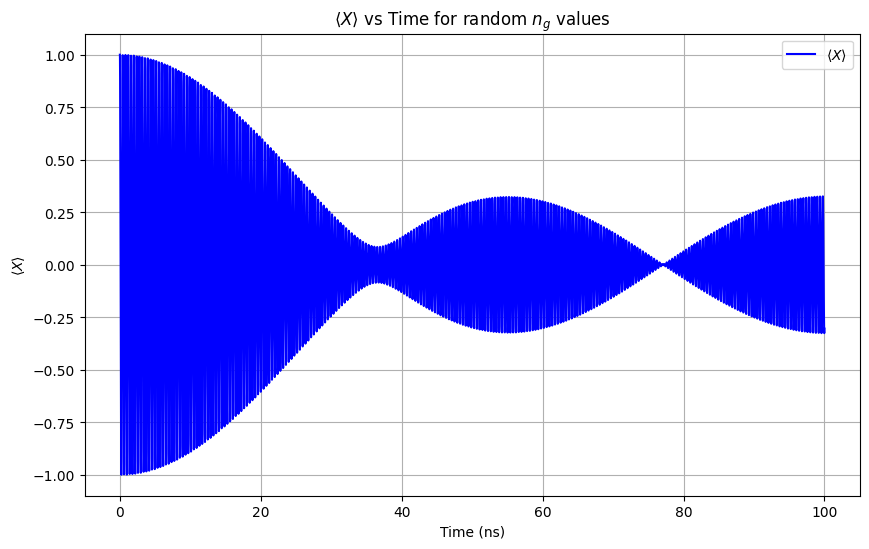

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(times, average_X, label=r'$\langle X \rangle$', color='blue')
plt.title(r'$\langle X \rangle$ vs Time for random $n_g$ values')
plt.xlabel('Time (ns)')
plt.ylabel(r'$\langle X \rangle$')
plt.grid()
plt.legend()
plt.show()

# C

In [7]:
N = 100
f_p = np.sqrt(8) # EJ, EC are in GHz and product set to 1. f_p is the plasma frequency in GHz.
EJ_over_EC = 64

N_random = 100
times = np.linspace(0, 500, 100000) # Time points for the simulation, in ns

ng_values = np.random.uniform(0, 1, N_random) # Random ng values
average_X = np.zeros(len(times), dtype = float)
for ng in ng_values:
    eta = np.sqrt(8 / EJ_over_EC)  # Calculate eta from the given ratio of Ej/Ec
    H = f_p * make_Hamiltonian(eta, ng, N) # Construct the Hamiltonian for the current ng. Hamiltonian is in GHz.
    evals = H.eigenenergies() # Get eigenvalues of the Hamiltonian  

    H_for_sesolve = 2* np.pi * qt.Qobj(np.diag(evals[:2] - evals[0]), dims=[[2], [2]]) # Hamiltonian for the two-level system
    psi_0 = (qt.fock(2,0) + qt.fock(2,1)).unit() # Initial state as a superposition of ground and excited states
    result = qt.sesolve(H_for_sesolve, psi_0, times, e_ops = [qt.sigmax()]) # Time evolution of the state, get expectation value of sigma_x
    average_X += np.real(result.expect[0])/ N_random # Accumulate the expectation values for averaging

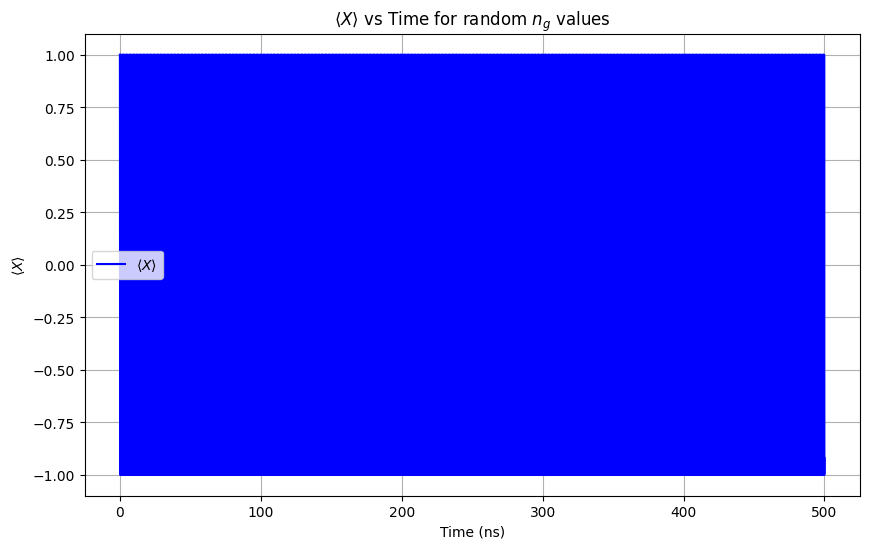

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(times, average_X, label=r'$\langle X \rangle$', color='blue')
plt.title(r'$\langle X \rangle$ vs Time for random $n_g$ values')
plt.xlabel('Time (ns)')
plt.ylabel(r'$\langle X \rangle$')
plt.grid()
plt.legend()
plt.show()

In [1]:
!jupyter nbconvert "P3.ipynb" --to html
!open "P3.html"

[NbConvertApp] Converting notebook P3.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 529141 bytes to P3.html
